# 🧠 Neural Network Training — From Scratch, Step by Step
### BrainerX AI Masterclass · Hands-on Notebook
---
**What you will do in this notebook:**
1. 📊 **Load & Explore** a real dataset (Breast Cancer — binary classification)
2. ⚙️ **Preprocess** the data (normalization, train/test split)
3. 🏗️ **Build** a Neural Network from scratch in PyTorch
4. 🏋️ **Train** the model and watch the loss drop epoch by epoch
5. 🎯 **Evaluate** with accuracy, confusion matrix, ROC-AUC
6. 🔍 **Visualize** weights, activations, and predictions

> 📌 **Dataset:** Breast Cancer Wisconsin — 569 samples, 30 features, 2 classes (Malignant / Benign)
---

## 📦 STEP 1 — Import Libraries
We need:
- `numpy / pandas` → data manipulation
- `matplotlib / seaborn` → visualization  
- `sklearn` → dataset + metrics
- `torch` → build and train the neural network

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

torch.manual_seed(42)
np.random.seed(42)

# Color palette for plots
plt.rcParams['figure.facecolor'] = '#0D1B2A'
plt.rcParams['axes.facecolor']   = '#162032'
plt.rcParams['axes.edgecolor']   = '#8D99AE'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1A2E45'
plt.rcParams['font.size']        = 11

TEAL   = '#0A9396'
GOLD   = '#E9C46A'
CORAL  = '#E76F51'
GREEN  = '#2DC653'

print('✅ All libraries imported!')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

✅ All libraries imported!
   PyTorch version : 2.7.1+cpu
   Device          : CPU


---
## 📊 STEP 2 — Load & Explore the Dataset

**Breast Cancer Wisconsin Dataset:**

| Property | Value |
|---|---|
| Samples | 569 |
| Features | 30 (radius, texture, perimeter, area, smoothness…) |
| Classes | 0 = Malignant, 1 = Benign |
| Goal | Predict if a tumor is malignant or benign |

This is a **binary classification** problem — the output is a single probability.

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')   # 0=Malignant, 1=Benign

print('=' * 50)
print(f'  Samples  : {X.shape[0]}')
print(f'  Features : {X.shape[1]}')
print(f'  Classes  : {list(data.target_names)}')
counts = y.value_counts()
print(f'  Malignant (0): {counts[0]}  ({counts[0]/len(y)*100:.1f}%)')
print(f'  Benign    (1): {counts[1]}  ({counts[1]/len(y)*100:.1f}%)')
print('=' * 50)
print()
X.head()

  Samples  : 569
  Features : 30
  Classes  : ['malignant', 'benign']
  Malignant (0): 212  (37.3%)
  Benign    (1): 357  (62.7%)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


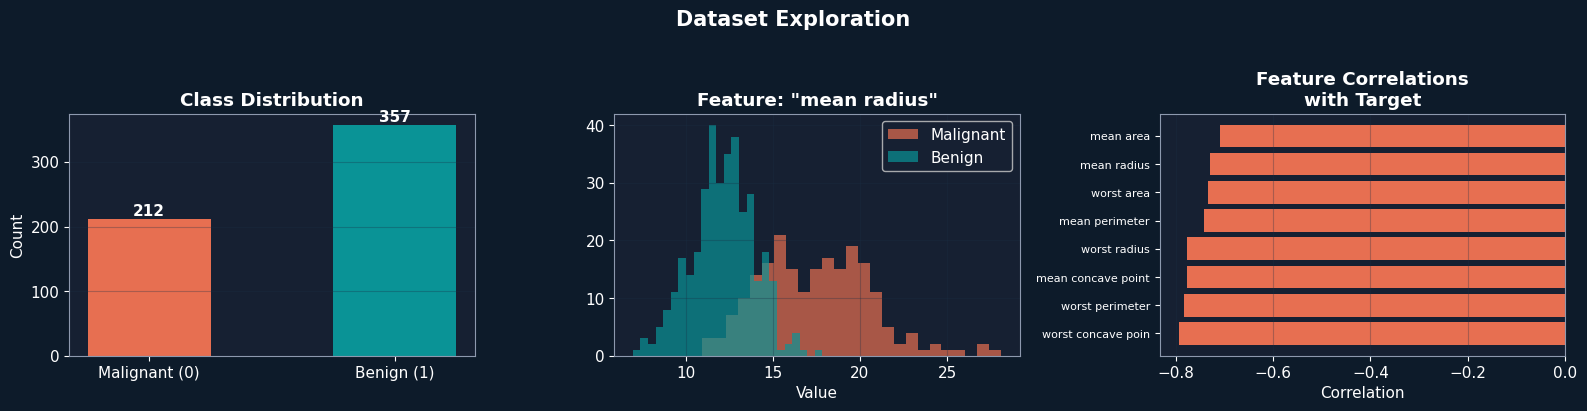

💡 Malignant tumors tend to have LARGER mean radius — the model will learn this!


In [3]:
# Visualize the dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Exploration', fontsize=15, fontweight='bold', y=1.02)

# Class distribution
ax = axes[0]
bars = ax.bar(['Malignant (0)', 'Benign (1)'], [counts[0], counts[1]],
              color=[CORAL, TEAL], width=0.5)
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(val), ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Feature histogram: mean radius by class
ax = axes[1]
ax.hist(X['mean radius'][y==0], bins=25, alpha=0.7, color=CORAL, label='Malignant')
ax.hist(X['mean radius'][y==1], bins=25, alpha=0.7, color=TEAL,  label='Benign')
ax.set_title('Feature: "mean radius"', fontweight='bold')
ax.set_xlabel('Value')
ax.legend()
ax.grid(alpha=0.3)

# Top feature correlations with target
ax = axes[2]
top_feats = X.corrwith(y.astype(float)).abs().nlargest(8).index
corr = X[top_feats].assign(target=y).corr()['target'].drop('target')
colors = [TEAL if v > 0 else CORAL for v in corr]
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels([f[:18] for f in corr.index], fontsize=8)
ax.set_title('Feature Correlations\nwith Target', fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(0, color='white', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 Malignant tumors tend to have LARGER mean radius — the model will learn this!')

---
## ⚙️ STEP 3 — Preprocess the Data

Before feeding data into a neural network we must:

1. **Split** into train / test sets (80% / 20%)
2. **Normalize** features — subtract mean, divide by std
   - Why? `area` ranges 0–2500 while `smoothness` ranges 0–0.16
   - Without normalization, large values dominate and training is unstable
3. **Convert** to PyTorch tensors

In [4]:
# 1. Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values,
    test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test  set: {X_test.shape[0]} samples')

# 2. Normalize (StandardScaler: mean=0, std=1)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train ONLY
X_test  = scaler.transform(X_test)        # same transform applied to test

print(f'\nAfter normalization:')
print(f'  Train mean : {X_train.mean():.4f}  (should be ≈ 0.0)')
print(f'  Train std  : {X_train.std():.4f}  (should be ≈ 1.0)')

# 3. Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)  # shape [n, 1]
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

# 4. DataLoader for batching
BATCH_SIZE   = 32
train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f'\nTensor shapes:')
print(f'  X_train_t : {X_train_t.shape}')
print(f'  y_train_t : {y_train_t.shape}')
print(f'\nDataLoader: {len(train_loader)} batches of {BATCH_SIZE} samples each')
print('\n✅ Preprocessing complete!')

Train set: 455 samples
Test  set: 114 samples

After normalization:
  Train mean : -0.0000  (should be ≈ 0.0)
  Train std  : 1.0000  (should be ≈ 1.0)

Tensor shapes:
  X_train_t : torch.Size([455, 30])
  y_train_t : torch.Size([455, 1])

DataLoader: 15 batches of 32 samples each

✅ Preprocessing complete!


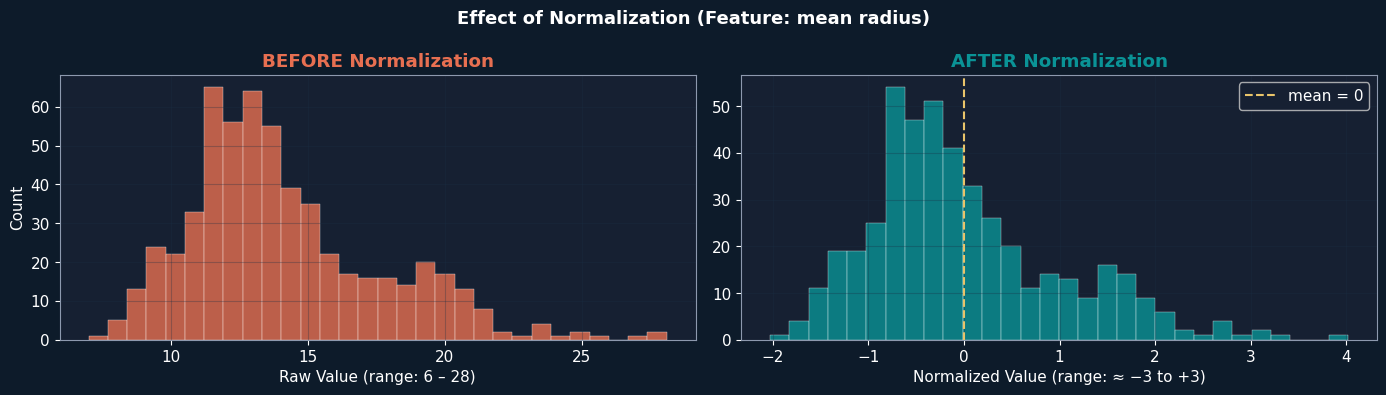

💡 All features are now on the same scale → faster and more stable training!


In [5]:
# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Effect of Normalization (Feature: mean radius)', fontsize=13, fontweight='bold')

axes[0].hist(X.values[:, 0], bins=30, color=CORAL, alpha=0.8, edgecolor='white', lw=0.3)
axes[0].set_title('BEFORE Normalization', fontweight='bold', color=CORAL)
axes[0].set_xlabel('Raw Value (range: 6 – 28)')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

axes[1].hist(X_train[:, 0], bins=30, color=TEAL, alpha=0.8, edgecolor='white', lw=0.3)
axes[1].set_title('AFTER Normalization', fontweight='bold', color=TEAL)
axes[1].set_xlabel('Normalized Value (range: ≈ −3 to +3)')
axes[1].axvline(0, color=GOLD, linestyle='--', lw=1.5, label='mean = 0')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 All features are now on the same scale → faster and more stable training!')

---
## 🏗️ STEP 4 — Build the Neural Network

Architecture:
```
Input (30 features)
    ↓
[Linear 30→64]  →  BatchNorm  →  ReLU  →  Dropout(0.3)
    ↓
[Linear 64→32]  →  BatchNorm  →  ReLU  →  Dropout(0.2)
    ↓
[Linear 32→16]  →  ReLU
    ↓
[Linear 16→1]   →  Sigmoid
    ↓
Output: probability  (0.0 = Malignant, 1.0 = Benign)
```

**Design decisions:**
- `BatchNorm` → stabilizes training, helps gradients flow smoothly
- `Dropout` → randomly turns off neurons → prevents overfitting
- `Sigmoid` → output is a probability between 0 and 1

In [6]:
class CancerNet(nn.Module):
    """
    Neural network for binary cancer classification.
    Input:  30 features
    Output: 1 probability (0=Malignant, 1=Benign)
    """
    def __init__(self, input_dim=30):
        super(CancerNet, self).__init__()

        # Layer 1: 30 → 64
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 64),  # weight matrix shape: [64 × 30]
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Layer 2: 64 → 32
        self.layer2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Layer 3: 32 → 16
        self.layer3 = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU()
        )
        # Output: 16 → 1
        self.output = nn.Sequential(
            nn.Linear(16, 1),
            nn.Sigmoid()   # squeeze to [0, 1]
        )

    def forward(self, x):
        x = self.layer1(x)   # 30 → 64
        x = self.layer2(x)   # 64 → 32
        x = self.layer3(x)   # 32 → 16
        x = self.output(x)   # 16 → 1
        return x


model = CancerNet(input_dim=30)
print(model)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')
print('\n💡 Each parameter is a weight or bias that will be adjusted during training!')

CancerNet(
  (layer1): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
  )
  (output): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total parameters     : 4,801
Trainable parameters : 4,801

💡 Each parameter is a weight or bias that will be adjusted during training!


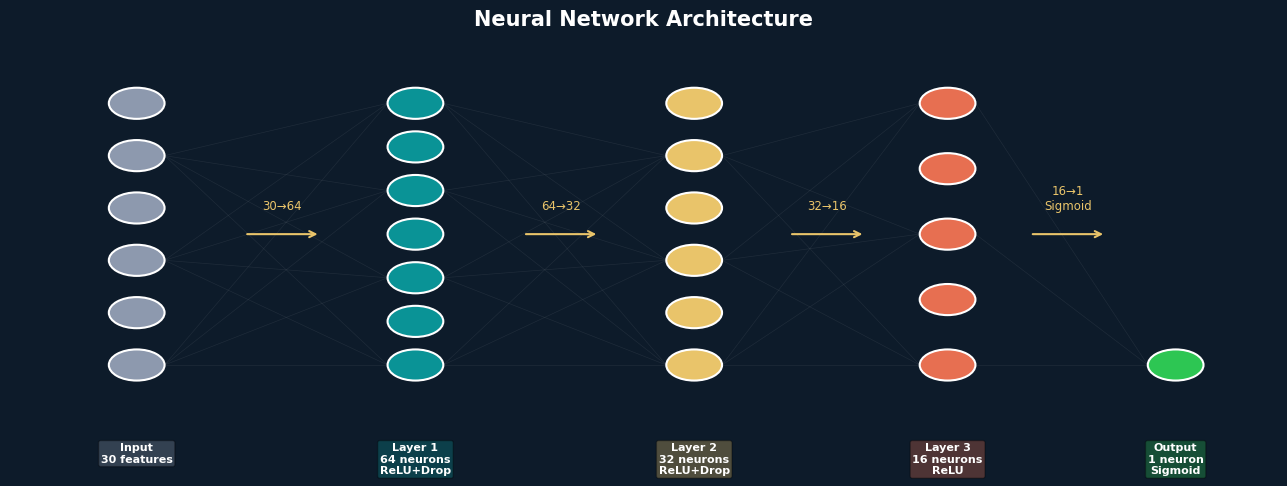

In [7]:
# Draw the architecture
fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 10); ax.set_ylim(-0.8, 5)
ax.axis('off')
fig.patch.set_facecolor('#0D1B2A')
ax.set_facecolor('#0D1B2A')
ax.set_title('Neural Network Architecture', fontsize=15, fontweight='bold', color='white', pad=15)

layers = [
    {'name': 'Input\n30 features',              'n': 6, 'x': 1.0, 'col': '#8D99AE'},
    {'name': 'Layer 1\n64 neurons\nReLU+Drop', 'n': 7, 'x': 3.2, 'col': TEAL},
    {'name': 'Layer 2\n32 neurons\nReLU+Drop', 'n': 6, 'x': 5.4, 'col': GOLD},
    {'name': 'Layer 3\n16 neurons\nReLU',      'n': 5, 'x': 7.4, 'col': CORAL},
    {'name': 'Output\n1 neuron\nSigmoid',       'n': 1, 'x': 9.2, 'col': GREEN},
]

neuron_pos = []
for L in layers:
    ys = np.linspace(0.5, 4.2, L['n'])
    neuron_pos.append((L['x'], ys))
    for y_n in ys:
        c = plt.Circle((L['x'], y_n), 0.22, color=L['col'], zorder=3, lw=1.5, ec='white')
        ax.add_patch(c)
    ax.text(L['x'], -0.6, L['name'], ha='center', va='top', fontsize=8,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc=L['col'], alpha=0.3))

# Connections (sampled)
for i in range(len(neuron_pos)-1):
    x1, ys1 = neuron_pos[i]
    x2, ys2 = neuron_pos[i+1]
    for y1 in ys1[::2]:
        for y2 in ys2[::2]:
            ax.plot([x1+0.22, x2-0.22], [y1, y2], color='white', alpha=0.07, lw=0.5, zorder=1)

arrow_lbls = ['30→64', '64→32', '32→16', '16→1\nSigmoid']
arrow_xs   = [2.1, 4.3, 6.4, 8.3]
for lbl, ax_x in zip(arrow_lbls, arrow_xs):
    ax.annotate('', xy=(ax_x+0.35, 2.35), xytext=(ax_x-0.25, 2.35),
                arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))
    ax.text(ax_x+0.05, 2.7, lbl, ha='center', fontsize=8.5, color=GOLD)

plt.tight_layout()
plt.show()

---
## 🏋️ STEP 5 — Train the Model

The training loop for each epoch:
```
For each mini-batch:
    1. Forward pass   → model makes predictions
    2. Compute loss   → how wrong is it?
    3. Backward pass  → compute gradients (backpropagation)
    4. Update weights → optimizer adjusts weights to reduce loss
```

**Hyperparameters:**
| Name | Value | Meaning |
|---|---|---|
| Epochs | 150 | Full passes over the training data |
| Learning rate | 0.001 | Step size for each weight update |
| Optimizer | Adam | Adaptive — adjusts lr per weight automatically |
| Loss | BCELoss | Binary Cross-Entropy — standard for binary classification |

In [8]:
EPOCHS = 150
LR     = 0.001

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Starting training for {EPOCHS} epochs...')
print('=' * 65)
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val Loss":>9}  {"Train Acc":>10}  {"Val Acc":>8}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):

    # ── TRAINING ─────────────────────────────────────────────────
    model.train()   # enables dropout and batchnorm
    for X_batch, y_batch in train_loader:
        # 1. Forward pass
        preds = model(X_batch)
        # 2. Loss
        loss = criterion(preds, y_batch)
        # 3. Backprop
        optimizer.zero_grad()
        loss.backward()
        # 4. Update
        optimizer.step()

    scheduler.step()

    # ── EVALUATION ───────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        tr_pred  = model(X_train_t)
        tr_loss  = criterion(tr_pred, y_train_t).item()
        tr_acc   = ((tr_pred > 0.5).float() == y_train_t).float().mean().item()

        va_pred  = model(X_test_t)
        va_loss  = criterion(va_pred, y_test_t).item()
        va_acc   = ((va_pred > 0.5).float() == y_test_t).float().mean().item()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {tr_loss:>11.4f}  {va_loss:>9.4f}  '
              f'{tr_acc*100:>9.2f}%  {va_acc*100:>7.2f}%')

print('-' * 65)
print(f'\n✅ Training complete!')
print(f'   Final Train Accuracy : {history["train_acc"][-1]*100:.2f}%')
print(f'   Final Val Accuracy   : {history["val_acc"][-1]*100:.2f}%')

Starting training for 150 epochs...
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-----------------------------------------------------------------
     1       0.6397     0.6412      94.07%    93.86%
    10       0.0822     0.1254      98.46%    95.61%
    20       0.0442     0.1018      98.68%    96.49%
    30       0.0335     0.0726      99.12%    98.25%
    40       0.0344     0.0821      99.34%    98.25%
    50       0.0211     0.0850      99.78%    95.61%
    60       0.0284     0.0702      99.12%    98.25%
    70       0.0218     0.0742      99.34%    95.61%
    80       0.0194     0.0673      99.34%    97.37%
    90       0.0199     0.0725      99.56%    97.37%
   100       0.0195     0.0769      99.78%    97.37%
   110       0.0210     0.0736      99.12%    96.49%
   120       0.0246     0.0699      99.12%    96.49%
   130       0.0211     0.0694      99.34%    97.37%
   140       0.0238     0.0797      99.12%    96.49%
   150       0.0172     0.0760      99.78%    98.2

---
## 📈 STEP 6 — Training Curves

**What to look for:**
- ✅ Both loss curves going **down** → the model is learning
- ✅ Both accuracy curves going **up** → model is improving  
- ⚠️ Train loss much lower than val loss → overfitting
- ⚠️ Both losses staying high → underfitting (model too simple)

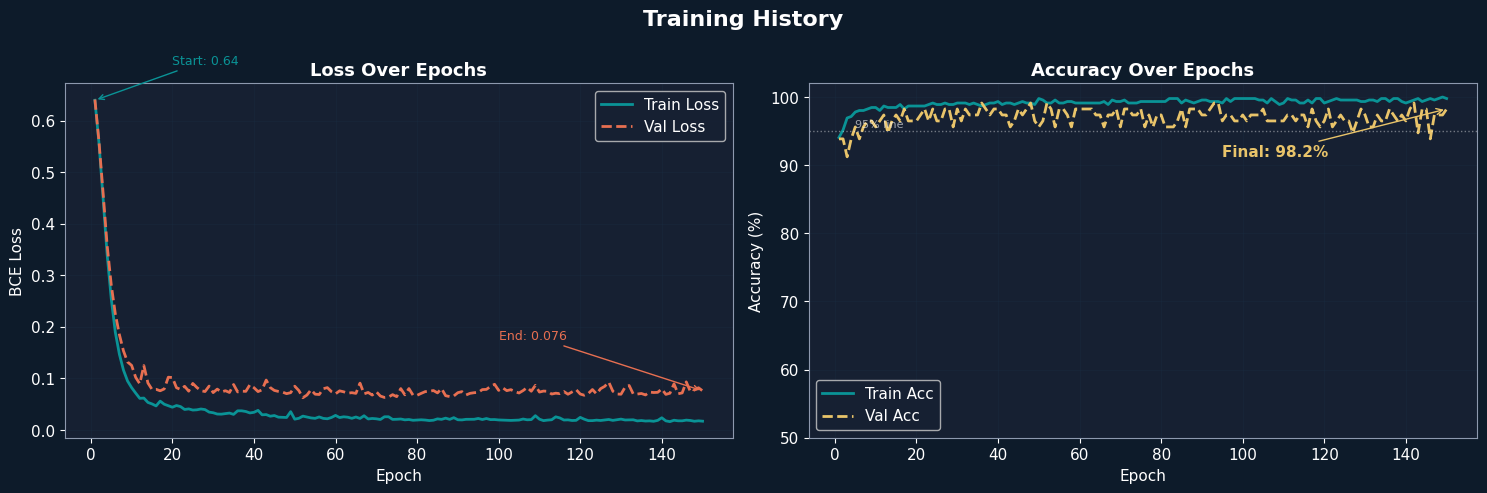


💡 Loss reduced by 88%
   Accuracy: 94% → 98.2%


In [9]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], color=TEAL,  lw=2, label='Train Loss')
ax.plot(epochs_range, history['val_loss'],   color=CORAL, lw=2, label='Val Loss', ls='--')
ax.set_title('Loss Over Epochs', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.annotate(f'Start: {history["train_loss"][0]:.2f}',
            xy=(1, history['train_loss'][0]),
            xytext=(20, history['train_loss'][0]+0.07),
            color=TEAL, fontsize=9, arrowprops=dict(arrowstyle='->', color=TEAL))
ax.annotate(f'End: {history["val_loss"][-1]:.3f}',
            xy=(EPOCHS, history['val_loss'][-1]),
            xytext=(EPOCHS-50, history['val_loss'][-1]+0.1),
            color=CORAL, fontsize=9, arrowprops=dict(arrowstyle='->', color=CORAL))

# Accuracy
ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']], color=TEAL, lw=2, label='Train Acc')
ax.plot(epochs_range, [a*100 for a in history['val_acc']],   color=GOLD, lw=2, label='Val Acc', ls='--')
ax.set_title('Accuracy Over Epochs', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim([50, 102])
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.axhline(95, color='white', ls=':', alpha=0.4, lw=1)
ax.text(5, 95.5, '95% line', color='white', fontsize=8, alpha=0.6)
final_acc = history['val_acc'][-1]*100
ax.annotate(f'Final: {final_acc:.1f}%',
            xy=(EPOCHS, final_acc),
            xytext=(EPOCHS-55, final_acc-7),
            color=GOLD, fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GOLD))

plt.tight_layout()
plt.show()
print(f'\n💡 Loss reduced by {(1-history["val_loss"][-1]/history["val_loss"][0])*100:.0f}%')
print(f'   Accuracy: {history["val_acc"][0]*100:.0f}% → {history["val_acc"][-1]*100:.1f}%')

---
## 🎯 STEP 7 — Evaluate the Model

We evaluate on the **test set** — data the model has NEVER seen during training.

| Metric | Meaning |
|---|---|
| **Accuracy** | % of all predictions that were correct |
| **Precision** | Of samples predicted Benign, how many truly were? |
| **Recall** | Of actual Benign samples, how many did we catch? |
| **F1 Score** | Balance between Precision and Recall |
| **ROC-AUC** | Model's ability to separate the two classes (1.0 = perfect) |

> 💡 In medical AI, **Recall** for Malignant is critical — we don't want to miss any cancer!

In [10]:
model.eval()
with torch.no_grad():
    probs = model(X_test_t).numpy().flatten()
    preds = (probs > 0.5).astype(int)

y_true = y_test
acc    = accuracy_score(y_true, preds)
auc    = roc_auc_score(y_true, probs)
cm     = confusion_matrix(y_true, preds)

print('=' * 50)
print('   TEST SET EVALUATION RESULTS')
print('=' * 50)
print(f'   Accuracy  : {acc*100:.2f}%')
print(f'   ROC-AUC   : {auc:.4f}')
print('-' * 50)
print(classification_report(y_true, preds, target_names=['Malignant','Benign']))

TN, FP, FN, TP = cm.ravel()
print('-' * 50)
print(f'   True Negatives  (correct Malignant) : {TN}')
print(f'   False Positives (said Benign, wrong): {FP}')
print(f'   False Negatives (said Malignant, wrong): {FN}')
print(f'   True Positives  (correct Benign)    : {TP}')
print('=' * 50)

   TEST SET EVALUATION RESULTS
   Accuracy  : 98.25%
   ROC-AUC   : 0.9960
--------------------------------------------------
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--------------------------------------------------
   True Negatives  (correct Malignant) : 40
   False Positives (said Benign, wrong): 2
   False Negatives (said Malignant, wrong): 0
   True Positives  (correct Benign)    : 72


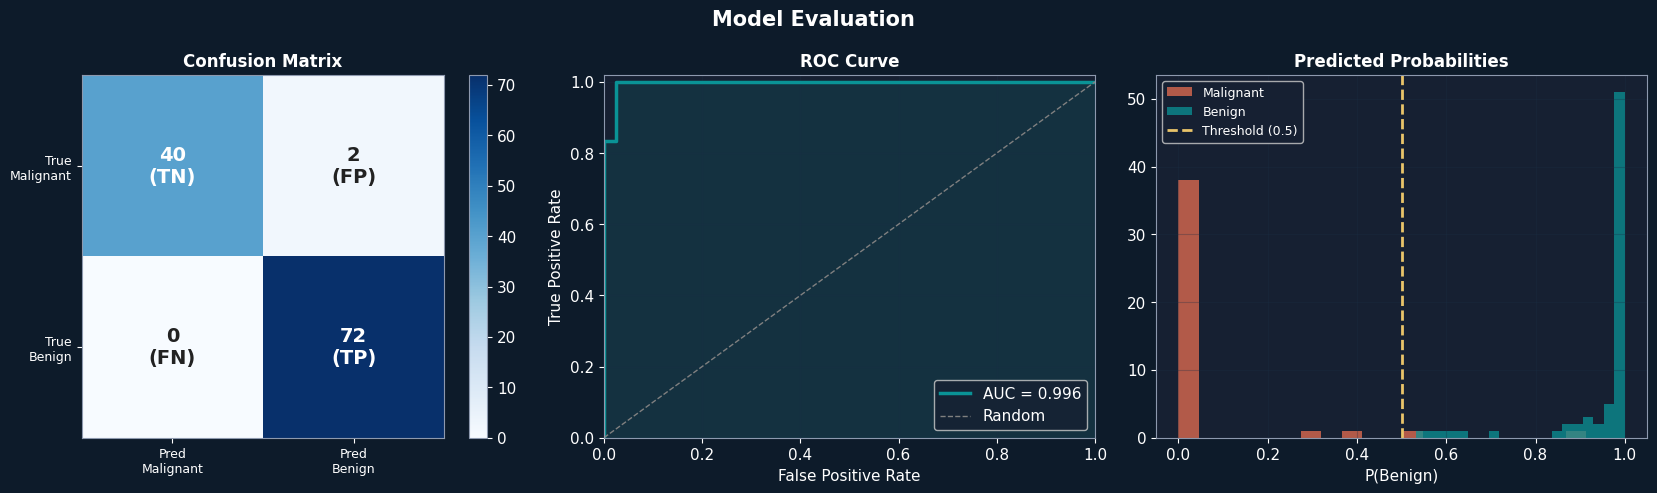


💡 Malignant predictions cluster near 0, Benign near 1 — good separation!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred\nMalignant','Pred\nBenign'], fontsize=9)
ax.set_yticklabels(['True\nMalignant','True\nBenign'], fontsize=9)
ax.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
lbl_map = {(0,0):'TN', (0,1):'FP', (1,0):'FN', (1,1):'TP'}
for i in range(2):
    for j in range(2):
        col = 'white' if cm[i,j] > cm.max()/2 else '#222'
        ax.text(j, i, f'{cm[i,j]}\n({lbl_map[(i,j)]})',
                ha='center', va='center', fontsize=14, fontweight='bold', color=col)
plt.colorbar(im, ax=ax)

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_true, probs)
ax.plot(fpr, tpr, color=TEAL, lw=2.5, label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1], color='gray', ls='--', lw=1, label='Random')
ax.fill_between(fpr, tpr, alpha=0.15, color=TEAL)
ax.set_title('ROC Curve', fontweight='bold', fontsize=12)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Probability distribution
ax = axes[2]
ax.hist(probs[y_true==0], bins=20, color=CORAL, alpha=0.75, label='Malignant')
ax.hist(probs[y_true==1], bins=20, color=TEAL,  alpha=0.75, label='Benign')
ax.axvline(0.5, color=GOLD, ls='--', lw=2, label='Threshold (0.5)')
ax.set_title('Predicted Probabilities', fontweight='bold', fontsize=12)
ax.set_xlabel('P(Benign)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('\n💡 Malignant predictions cluster near 0, Benign near 1 — good separation!')

---
## 🔍 STEP 8 — Look Inside the Network

Let's visualize what the network has *actually learned* — the weight distributions and the activation patterns for a real sample.

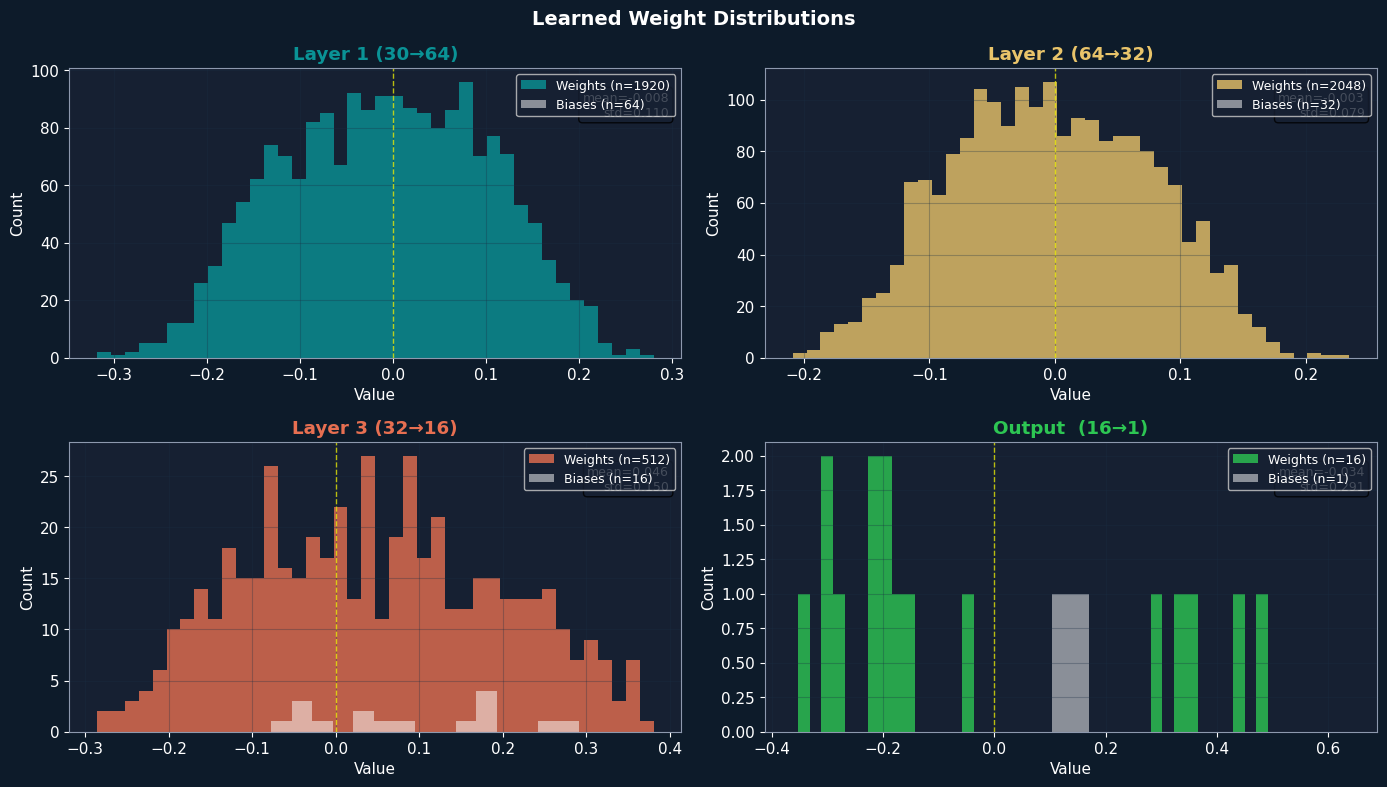

💡 Weights spread around 0 — training pushed them to useful values!


In [12]:
# Weight distributions per layer
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Learned Weight Distributions', fontsize=14, fontweight='bold')

layer_info = [
    ('Layer 1 (30→64)', model.layer1[0], TEAL),
    ('Layer 2 (64→32)', model.layer2[0], GOLD),
    ('Layer 3 (32→16)', model.layer3[0], CORAL),
    ('Output  (16→1)',  model.output[0], GREEN),
]
for ax, (name, module, color) in zip(axes.flat, layer_info):
    w = module.weight.data.numpy().flatten()
    b = module.bias.data.numpy().flatten()
    ax.hist(w, bins=40, color=color, alpha=0.8, label=f'Weights (n={len(w)})')
    ax.hist(b, bins=15, color='white', alpha=0.5, label=f'Biases (n={len(b)})')
    ax.set_title(name, fontweight='bold', color=color)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.axvline(0, color='yellow', lw=1, ls='--', alpha=0.7)
    ax.grid(alpha=0.3)
    ax.text(0.98, 0.92, f'mean={w.mean():.3f}\nstd={w.std():.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='#162032', alpha=0.8))
plt.tight_layout(); plt.show()
print('💡 Weights spread around 0 — training pushed them to useful values!')

Sample #5  |  True: Benign  |  Predicted: Benign  |  P=0.9925


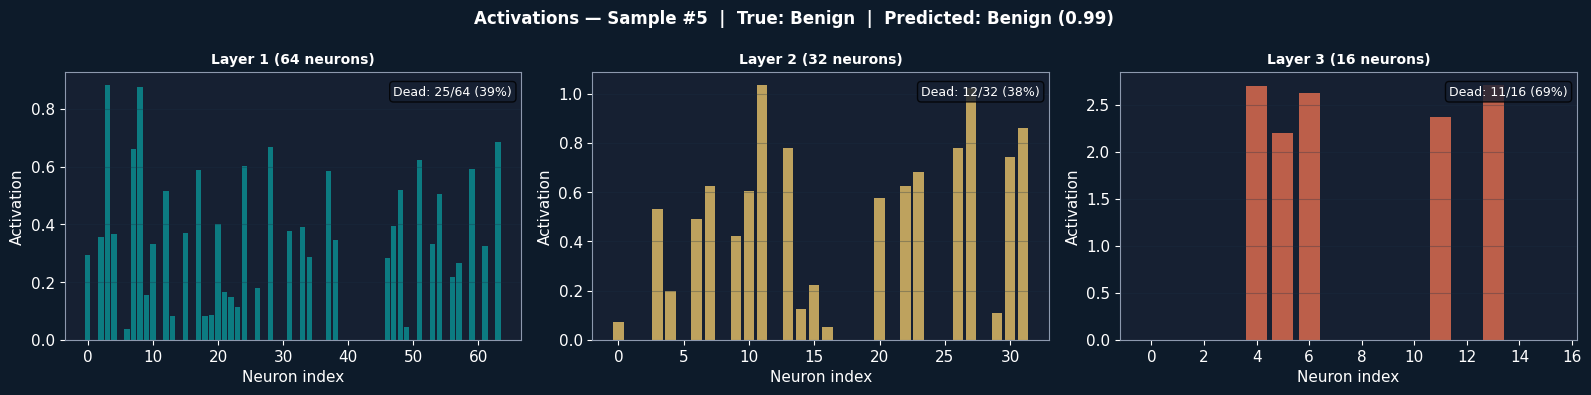


💡 Zero bars = neurons blocked by ReLU for this input
   Non-zero bars = neurons that contributed to the prediction


In [13]:
# Activation heatmap for one sample
sample_idx = 5
sample     = X_test_t[sample_idx].unsqueeze(0)
truth      = 'Benign' if y_test[sample_idx]==1 else 'Malignant'

activations = {}
def hook(name):
    def fn(module, inp, out):
        activations[name] = out.detach().numpy().flatten()
    return fn

model.layer1[2].register_forward_hook(hook('l1'))
model.layer2[2].register_forward_hook(hook('l2'))
model.layer3[1].register_forward_hook(hook('l3'))

model.eval()
with torch.no_grad():
    p = model(sample).item()
predicted = 'Benign' if p > 0.5 else 'Malignant'
print(f'Sample #{sample_idx}  |  True: {truth}  |  Predicted: {predicted}  |  P={p:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Activations — Sample #{sample_idx}  |  True: {truth}  |  Predicted: {predicted} ({p:.2f})',
             fontsize=12, fontweight='bold')
for ax, (key, title, col) in zip(axes, [('l1','Layer 1 (64 neurons)',TEAL),
                                          ('l2','Layer 2 (32 neurons)',GOLD),
                                          ('l3','Layer 3 (16 neurons)',CORAL)]):
    vals = activations[key]
    dead = (vals==0).sum()
    ax.bar(range(len(vals)), vals, color=col, alpha=0.8, width=0.8)
    ax.axhline(0, color='white', lw=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Neuron index'); ax.set_ylabel('Activation')
    ax.text(0.98,0.95, f'Dead: {dead}/{len(vals)} ({dead/len(vals)*100:.0f}%)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='#162032', alpha=0.8))
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('\n💡 Zero bars = neurons blocked by ReLU for this input')
print('   Non-zero bars = neurons that contributed to the prediction')

---
## 🔮 STEP 9 — Predictions & Final Summary

In [14]:
# Predict on 20 test samples
model.eval()
with torch.no_grad():
    all_probs = model(X_test_t).numpy().flatten()

print('=' * 62)
print(f'{"#":>3}  {"True":>11}  {"Predicted":>11}  {"Confidence":>11}  {"✓/✗":>5}')
print('-' * 62)
for i in range(20):
    true_lbl = 'Benign' if y_test[i]==1 else 'Malignant'
    pred_lbl = 'Benign' if all_probs[i]>0.5 else 'Malignant'
    correct  = '✅' if true_lbl==pred_lbl else '❌'
    conf     = all_probs[i] if all_probs[i]>0.5 else 1-all_probs[i]
    print(f'{i+1:>3}  {true_lbl:>11}  {pred_lbl:>11}  {conf:>10.1%}  {correct:>5}')
print('-' * 62)
wrong = sum(1 for i in range(len(y_test)) if (all_probs[i]>0.5) != y_test[i])
print(f'\nMistakes on full test set: {wrong}/{len(y_test)} ({wrong/len(y_test)*100:.1f}%)')

  #         True    Predicted   Confidence    ✓/✗
--------------------------------------------------------------
  1    Malignant    Malignant       99.8%      ✅
  2       Benign       Benign      100.0%      ✅
  3    Malignant    Malignant       98.6%      ✅
  4       Benign       Benign       55.8%      ✅
  5    Malignant    Malignant      100.0%      ✅
  6       Benign       Benign       99.2%      ✅
  7       Benign       Benign       99.9%      ✅
  8    Malignant    Malignant      100.0%      ✅
  9    Malignant    Malignant       99.8%      ✅
 10    Malignant    Malignant      100.0%      ✅
 11       Benign       Benign       99.5%      ✅
 12    Malignant    Malignant       99.8%      ✅
 13       Benign       Benign       99.8%      ✅
 14    Malignant    Malignant       99.6%      ✅
 15    Malignant    Malignant       99.4%      ✅
 16       Benign       Benign       93.3%      ✅
 17       Benign       Benign       62.4%      ✅
 18       Benign       Benign       97.5%      ✅
 19  

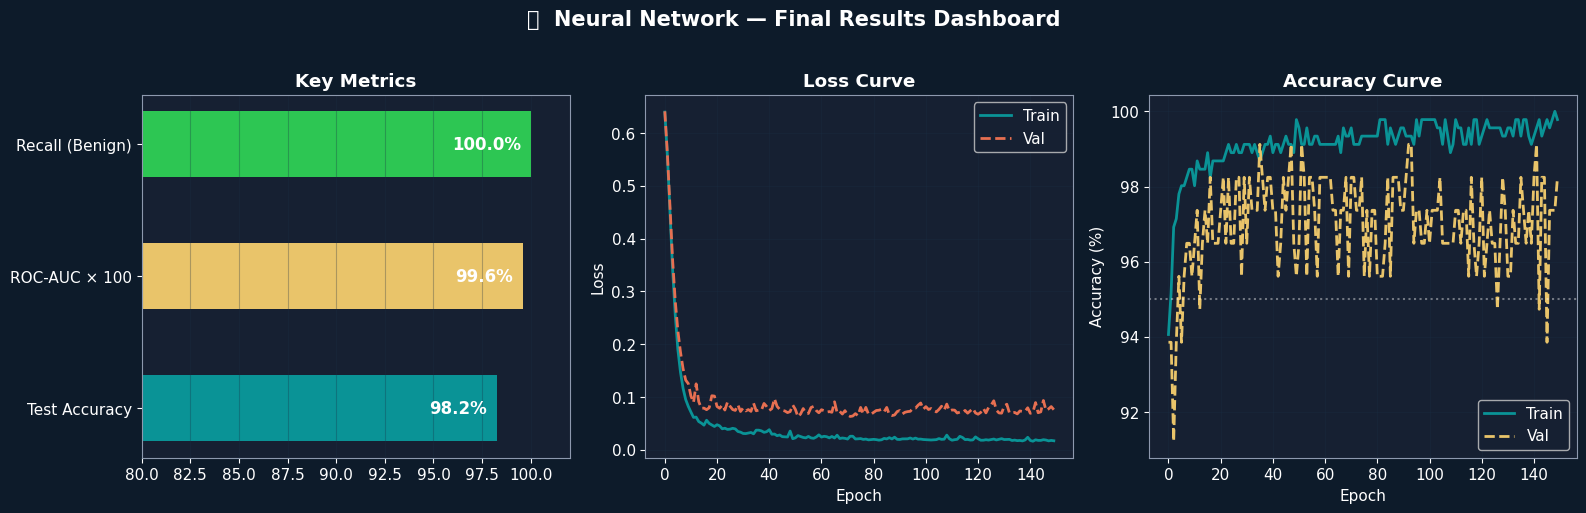


  🎉  COMPLETE SUMMARY
  Dataset      : Breast Cancer Wisconsin (569 samples)
  Architecture : 30 → 64 → 32 → 16 → 1 (Sigmoid)
  Optimizer    : Adam  |  Loss: Binary Cross-Entropy
  Epochs       : 150  |  Batch size: 32
-------------------------------------------------------
  Test Accuracy    : 98.25%
  ROC-AUC          : 0.9960
  Correct / Wrong  : 112 / 2


In [15]:
# ── Final Summary Dashboard ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🧠  Neural Network — Final Results Dashboard',
             fontsize=15, fontweight='bold', y=1.02)

# Metric bars
metrics = [('Test Accuracy', accuracy_score(y_test,preds)*100, '%', TEAL),
           ('ROC-AUC × 100', auc*100, '%', GOLD),
           ('Recall (Benign)', 
            cm[1,1]/(cm[1,0]+cm[1,1])*100, '%', GREEN)]

ax = axes[0]
bars = ax.barh([m[0] for m in metrics], [m[1] for m in metrics],
               color=[m[3] for m in metrics], height=0.5)
ax.set_xlim(80, 102)
ax.set_title('Key Metrics', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, m in zip(bars, metrics):
    ax.text(bar.get_width()-0.5, bar.get_y()+bar.get_height()/2,
            f'{m[1]:.1f}{m[2]}', va='center', ha='right', fontweight='bold', fontsize=12)

# Loss curves
ax = axes[1]
ax.plot(history['train_loss'], color=TEAL,  lw=2, label='Train')
ax.plot(history['val_loss'],   color=CORAL, lw=2, label='Val', ls='--')
ax.set_title('Loss Curve', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy curves
ax = axes[2]
ax.plot([a*100 for a in history['train_acc']], color=TEAL,  lw=2, label='Train')
ax.plot([a*100 for a in history['val_acc']],   color=GOLD,  lw=2, label='Val', ls='--')
ax.axhline(95, color='white', ls=':', alpha=0.4)
ax.set_title('Accuracy Curve', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('  🎉  COMPLETE SUMMARY')
print('='*55)
print(f'  Dataset      : Breast Cancer Wisconsin (569 samples)')
print(f'  Architecture : 30 → 64 → 32 → 16 → 1 (Sigmoid)')
print(f'  Optimizer    : Adam  |  Loss: Binary Cross-Entropy')
print(f'  Epochs       : {EPOCHS}  |  Batch size: {BATCH_SIZE}')
print('-'*55)
print(f'  Test Accuracy    : {accuracy_score(y_test,preds)*100:.2f}%')
print(f'  ROC-AUC          : {auc:.4f}')
print(f'  Correct / Wrong  : {len(y_test)-wrong} / {wrong}')
print('='*55)